In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import xgboost as xgb

from sklearn.model_selection import  RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
)

import shap
import mlflow
import mlflow.xgboost
from mlflow.models import infer_signature

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

/Users/erikbayerlein/Documents/clutch-or-predict/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_parquet('../data/match_dataset.parquet')
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values(by='match_date').reset_index(drop=True)
df

,t1_id,map_stat_id,t1_kills_avg,t1_kills_median,t1_kills_p25,t1_kills_p75,t1_kills_std,t1_clutches_avg,t1_clutches_median,t1_clutches_p25,...,t2_kast_median,t2_kast_p25,t2_kast_p75,t2_kast_std,match_date,winner,map_encoding,event_weight,t1_elo,t2_elo
0,11982,163828,17.2,18.0,16.0,20.0,3.346640,0.4,0.0,0.0,...,133.3,116.6,141.6,15.152063,2023-10-04 13:00:00+00:00,0,0,0.000000,1500.000000,1500.000000
1,11518,163825,14.4,13.0,12.0,17.0,4.669047,0.0,0.0,0.0,...,156.0,138.6,165.1,16.080050,2023-10-04 13:00:00+00:00,1,1,0.000000,1500.000000,1500.000000
2,7969,163823,10.6,10.0,8.0,11.0,3.911521,0.0,0.0,0.0,...,132.1,132.1,146.4,14.170109,2023-10-04 13:00:00+00:00,1,0,0.000000,1500.000000,1500.000000
3,11321,163824,20.0,20.0,16.0,21.0,5.787918,0.2,0.0,0.0,...,150.4,137.1,164.7,19.671223,2023-10-04 13:00:00+00:00,1,0,0.000000,1500.000000,1500.000000
4,11861,163821,13.6,13.0,11.0,13.0,6.308724,0.6,0.0,0.0,...,141.7,125.0,150.0,25.287250,2023-10-04 13:00:00+00:00,0,0,0.000000,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43055,13605,216045,16.0,16.0,15.0,17.0,1.581139,0.4,0.0,0.0,...,126.7,126.7,128.3,8.811356,2025-12-28 05:40:00+00:00,0,3,0.022298,1510.288978,1489.711022
43056,13440,216039,16.2,20.0,12.0,20.0,5.848077,0.0,0.0,0.0,...,120.8,120.8,133.3,17.356180,2025-12-28 06:00:00+00:00,0,8,0.022298,1532.081026,1520.989787
43057,13440,216043,14.6,15.0,13.0,17.0,4.505552,0.2,0.0,0.0,...,118.3,101.7,123.3,32.616989,2025-12-28 06:00:00+00:00,0,5,0.022298,1537.137331,1515.933483
43058,13370,216047,12.8,12.0,9.0,14.0,5.805170,0.4,0.0,0.0,...,126.7,118.3,135.0,33.956929,2025-12-28 06:30:00+00:00,0,4,0.022298,1479.900290,1502.172053


In [4]:
split_date = '2025-11-30'

train_mask = df['match_date'] <= split_date
test_mask = df['match_date'] > split_date

In [5]:
target_col = 'winner'
weight_col = 'event_weight'
cols_to_drop = [target_col, weight_col, 'match_date', 'map_stat_id', 't1_id', 't2_id']

In [6]:
swing_cols = [c for c in df.columns if 'swing' in c]
rating_cols = [c for c in df.columns if 'rating' in c]
df = df.drop(columns=swing_cols)
df = df.drop(columns=rating_cols)

In [7]:
X_train = df.loc[train_mask].drop(columns=cols_to_drop)
y_train = df.loc[train_mask, target_col]
w_train = df.loc[train_mask, weight_col]

In [8]:
X_prod = df.loc[test_mask].drop(columns=cols_to_drop)
y_prod = df.loc[test_mask, target_col]

In [9]:
print(f"Split Date: {split_date}")
print(f"Training Samples (Historical): {len(X_train)}")
print(f"Production Samples (Future):   {len(X_prod)}")

Split Date: 2025-11-30
Training Samples (Historical): 42148
Production Samples (Future):   912


In [10]:
param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'learning_rate': [0.001, 0.005, 0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.4, 0.5, 0.6],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 4, 5]
}

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

In [12]:
print("\nStarting Random Search on historical data...")
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_log_loss',
    cv=tscv,
    verbose=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train, sample_weight=w_train)

best_model = random_search.best_estimator_

print("-" * 30)
print(f"Best Params: {random_search.best_params_}")
print("-" * 30)


Starting Random Search on historical data...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.5, gamma=0.2, learning_rate=0.03, max_depth=8, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=0.8;, score=-0.686 total time=   0.6s
[CV 1/5] END colsample_bytree=0.5, gamma=0.2, learning_rate=0.03, max_depth=8, min_child_weight=3, n_estimators=500, reg_alpha=1, reg_lambda=1, subsample=0.8;, score=-0.686 total time=   0.6s
[CV 1/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=1000, reg_alpha=0.1, reg_lambda=5, subsample=0.8;, score=-0.686 total time=   1.0s
[CV 1/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=1000, reg_alpha=0.1, reg_lambda=5, subsample=0.8;, score=-0.686 total time=   1.0s
[CV 1/5] END colsample_bytree=0.6, gamma=0, learning_rate=0.001, max_depth=6, min_child_weight=1, n_estimators=1000, reg_a

In [13]:
if len(X_prod) > 0:
    preds_proba = best_model.predict_proba(X_prod)[:, 1]
    preds_class = best_model.predict(X_prod)

    prod_log_loss = log_loss(y_prod, preds_proba)
    prod_acc = accuracy_score(y_prod, preds_class)

    print(f"RESULTS ON DATA AFTER {split_date}:")
    print(f"Log Loss: {prod_log_loss:.4f}")
    print(f"Accuracy: {prod_acc:.2%}")
else:
    print("No data found after 2025-11-30 to test.")

RESULTS ON DATA AFTER 2025-11-30:
Log Loss: 0.4412
Accuracy: 82.02%


In [14]:
signature = infer_signature(X_train, best_model.predict_proba(X_train))

model_info = {
    "model_type": "XGBoost Classifier",
    "training_samples": len(X_train),
    "test_samples": len(X_prod),
    "split_date": split_date,
    "test_accuracy": f"{prod_acc:.4f}",
    "test_log_loss": f"{prod_log_loss:.4f}",
    "features": list(X_train.columns),
    "n_features": len(X_train.columns),
    "best_params": random_search.best_params_,
    "cv_best_score": random_search.best_score_
}

print("Saving model with MLflow...")
print(f"Model metadata: {model_info}")

Saving model with MLflow...
Model metadata: {'model_type': 'XGBoost Classifier', 'training_samples': 42148, 'test_samples': 912, 'split_date': '2025-11-30', 'test_accuracy': '0.8202', 'test_log_loss': '0.4412', 'features': ['t1_kills_avg', 't1_kills_median', 't1_kills_p25', 't1_kills_p75', 't1_kills_std', 't1_clutches_avg', 't1_clutches_median', 't1_clutches_p25', 't1_clutches_p75', 't1_clutches_std', 't1_headshot_avg', 't1_headshot_median', 't1_headshot_p25', 't1_headshot_p75', 't1_headshot_std', 't1_flash_avg', 't1_flash_median', 't1_flash_p25', 't1_flash_p75', 't1_flash_std', 't1_assist_avg', 't1_assist_median', 't1_assist_p25', 't1_assist_p75', 't1_assist_std', 't1_deaths_avg', 't1_deaths_median', 't1_deaths_p25', 't1_deaths_p75', 't1_deaths_std', 't1_traded_deaths_avg', 't1_traded_deaths_median', 't1_traded_deaths_p25', 't1_traded_deaths_p75', 't1_traded_deaths_std', 't1_adr_avg', 't1_adr_median', 't1_adr_p25', 't1_adr_p75', 't1_adr_std', 't1_opening_kills_avg', 't1_opening_kills_

/Users/erikbayerlein/Documents/clutch-or-predict/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [15]:
model_path = "../models/cs2_match_predictor"

native_booster = best_model.get_booster()

mlflow.xgboost.save_model(
    xgb_model=native_booster,
    path=model_path,
    signature=signature,
    input_example=X_train.iloc[:5],
)

print(f"✓ Model saved to: {model_path}")
print(f"  - Model artifact: {model_path}/model.xgb")
print(f"  - MLmodel file: {model_path}/MLmodel")
print(f"  - Conda env: {model_path}/conda.yaml")
print(f"  - Requirements: {model_path}/requirements.txt")

2026/01/07 09:00:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ Model saved to: ../models/cs2_match_predictor
  - Model artifact: ../models/cs2_match_predictor/model.xgb
  - MLmodel file: ../models/cs2_match_predictor/MLmodel
  - Conda env: ../models/cs2_match_predictor/conda.yaml
  - Requirements: ../models/cs2_match_predictor/requirements.txt


In [16]:
loaded_model = mlflow.xgboost.load_model(model_path)

dtest = xgb.DMatrix(X_prod.iloc[:5], enable_categorical=True)

test_pred = loaded_model.predict(dtest)
original_pred = best_model.predict_proba(X_prod.iloc[:5])[:, 1]

assert np.allclose(test_pred, original_pred), "Loaded model predictions don't match!"

print("✓ Model loading verified successfully!")
print(f"\nSample predictions (first 5 test samples):")
print(f"Original: {original_pred}")
print(f"Loaded:   {test_pred}")

✓ Model loading verified successfully!

Sample predictions (first 5 test samples):
Original: [0.08000786 0.73244953 0.09228709 0.8945999  0.8930988 ]
Loaded:   [0.08000786 0.73244953 0.09228709 0.8945999  0.8930988 ]


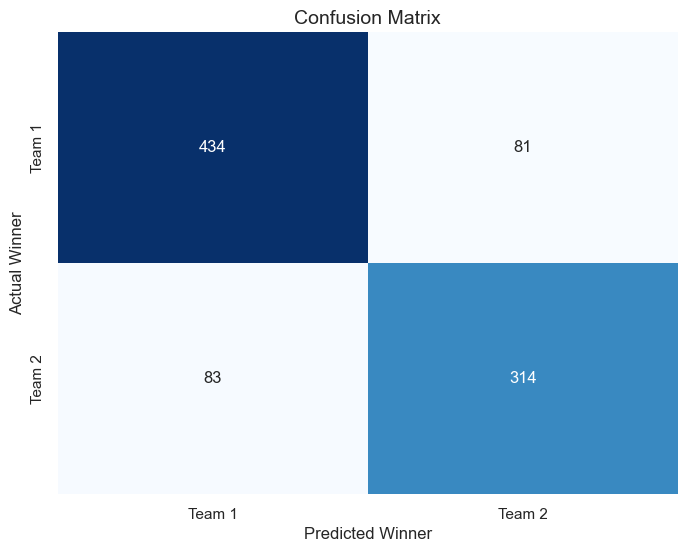

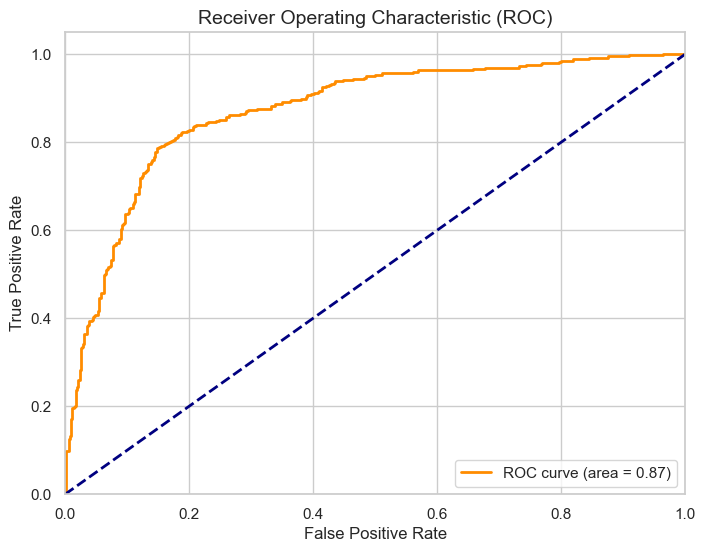

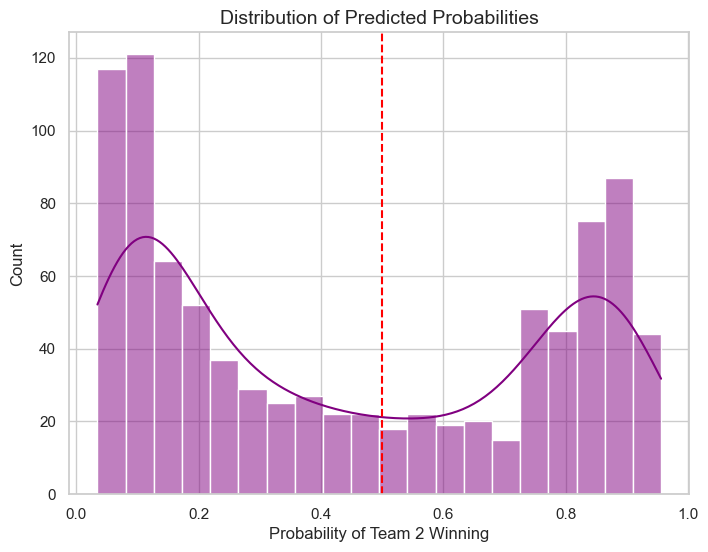

/var/folders/rp/lcxnvlln3qq7ym11pq6qf0w00000gn/T/ipykernel_95636/2622091131.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


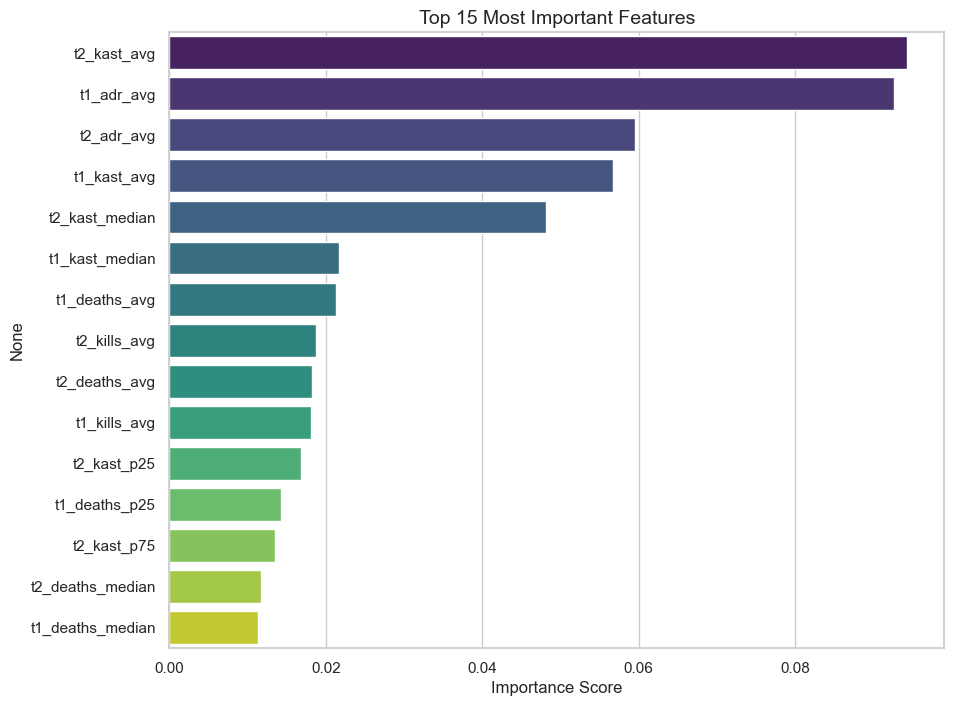

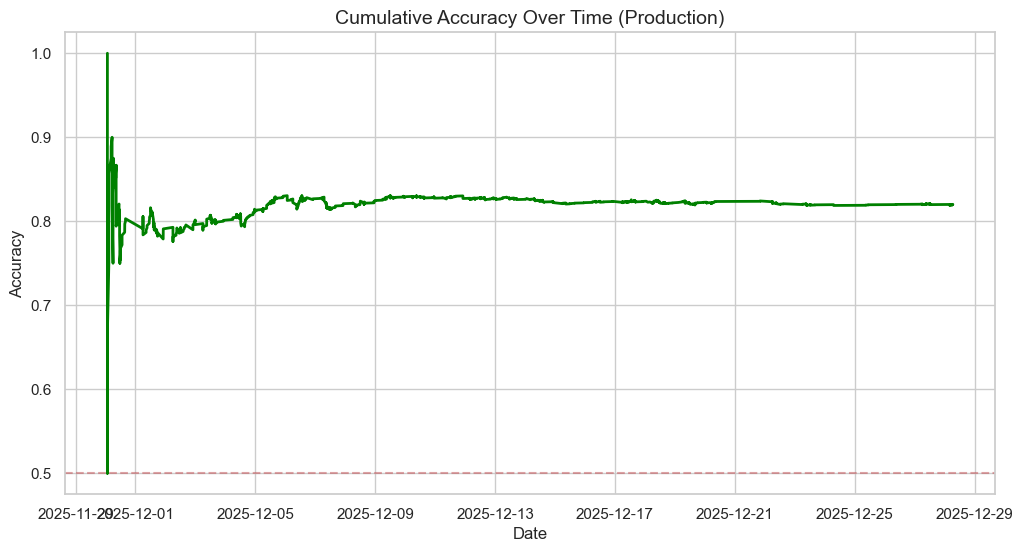

In [17]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_prod, preds_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Winner')
plt.ylabel('Actual Winner')
plt.xticks([0.5, 1.5], ['Team 1', 'Team 2'])
plt.yticks([0.5, 1.5], ['Team 1', 'Team 2'])
plt.show()

plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_prod, preds_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.show()

# --- Plot 3: Distribution of Probabilities ---
plt.figure(figsize=(8, 6))
sns.histplot(preds_proba, bins=20, kde=True, color='purple')
plt.title('Distribution of Predicted Probabilities', fontsize=14)
plt.xlabel('Probability of Team 2 Winning')
plt.axvline(0.5, color='red', linestyle='--')
plt.show()

# --- Plot 4: Feature Importance ---
plt.figure(figsize=(10, 8))
importances = best_model.feature_importances_
feature_names = X_prod.columns
indices = np.argsort(importances)[::-1][:15]

sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Top 15 Most Important Features', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

# --- Plot 5: Cumulative Accuracy ---
plt.figure(figsize=(12, 6))
dates_prod = df.loc[X_prod.index, 'match_date']
correct_preds = (preds_class == y_prod).astype(int)

perf_df = pd.DataFrame({'date': dates_prod, 'correct': correct_preds})
perf_df = perf_df.sort_values('date')
perf_df['cumulative_accuracy'] = perf_df['correct'].expanding().mean()

plt.plot(perf_df['date'], perf_df['cumulative_accuracy'], color='green', lw=2)
plt.title('Cumulative Accuracy Over Time (Production)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.show()

### Model Explainability (XAI)

In [34]:
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_model)

sample_size = len(X_prod)
X_sample = X_prod.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP values computed for {sample_size} samples")
print(f"Shape: {shap_values.shape}")

Initializing SHAP TreeExplainer...
✓ SHAP values computed for 912 samples
Shape: (912, 123)


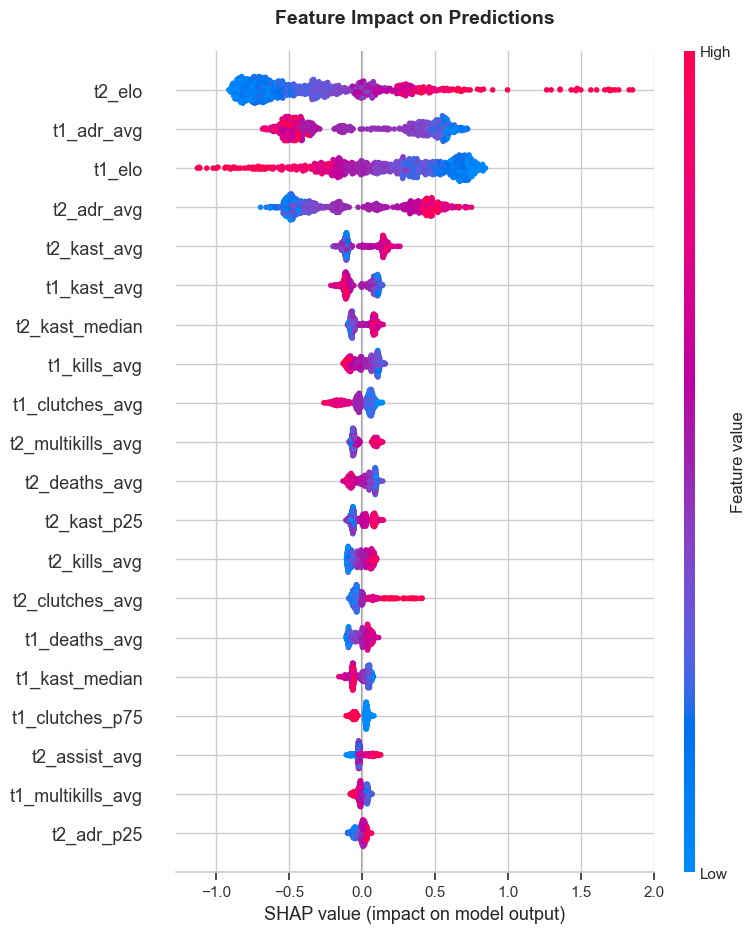

In [35]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title('Feature Impact on Predictions', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

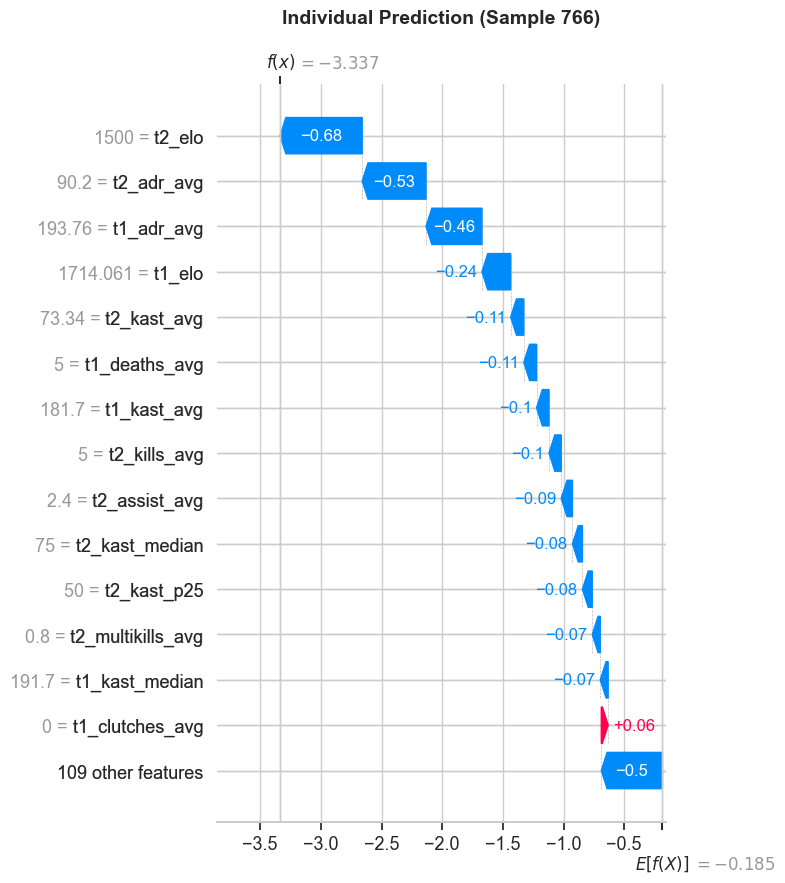

Actual Outcome: Team 1 Win
Predicted Probability (Team 2 Win): 0.034


In [36]:
if len(X_sample) > 0:
    pred_idx = np.argmax(np.abs(preds_proba[:sample_size] - 0.5))
    
    shap_explanation = shap.Explanation(
        values=shap_values[pred_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[pred_idx].values,
        feature_names=X_sample.columns.tolist()
    )
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(shap_explanation, max_display=15, show=False)
    plt.title(f'Individual Prediction (Sample {pred_idx})', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    actual_outcome = "Team 2 Win" if y_prod.iloc[pred_idx] == 1 else "Team 1 Win"
    predicted_prob = preds_proba[pred_idx]
    print(f"Actual Outcome: {actual_outcome}")
    print(f"Predicted Probability (Team 2 Win): {predicted_prob:.3f}")

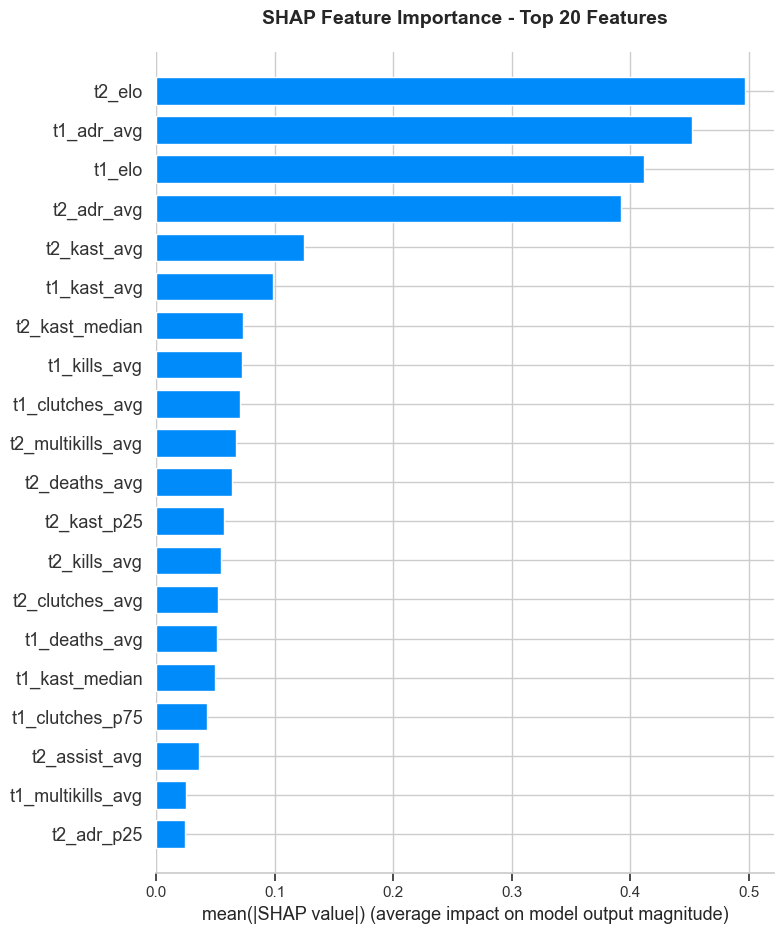

In [ ]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=20)
plt.title('SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

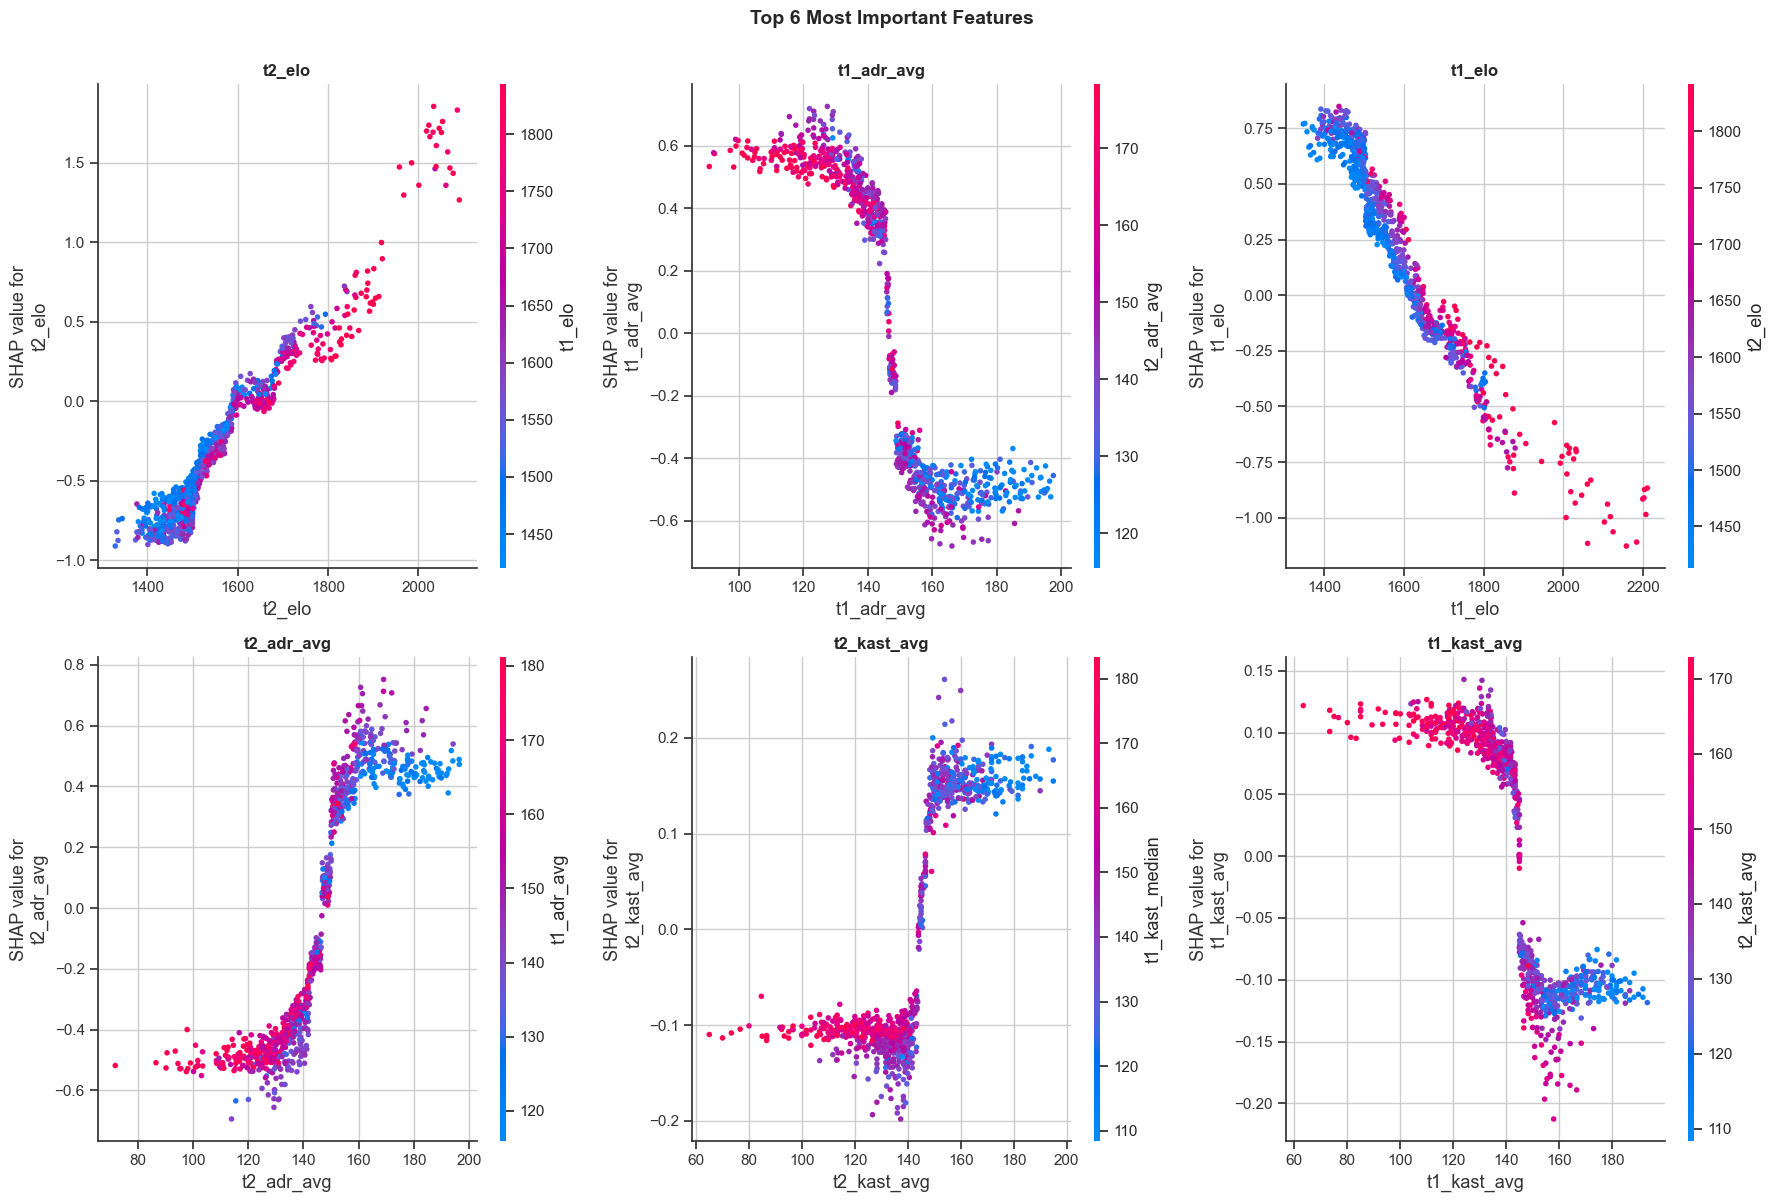


Top 6 Features by Mean |SHAP| Value:
1. t2_elo: 0.4965
2. t1_adr_avg: 0.4519
3. t1_elo: 0.4113
4. t2_adr_avg: 0.3926
5. t2_kast_avg: 0.1247
6. t1_kast_avg: 0.0982


In [48]:
top_n_features = 6
mean_abs_shap = np.abs(shap_values).mean(0)
top_feature_indices = np.argsort(mean_abs_shap)[-top_n_features:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature_idx in enumerate(top_feature_indices):
    feature_name = X_sample.columns[feature_idx]
    
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_sample,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{feature_name}', fontsize=12, fontweight='bold')

plt.suptitle('Top 6 Most Important Features', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nTop 6 Features by Mean |SHAP| Value:")
for i, feature_idx in enumerate(top_feature_indices, 1):
    print(f"{i}. {X_sample.columns[feature_idx]}: {mean_abs_shap[feature_idx]:.4f}")

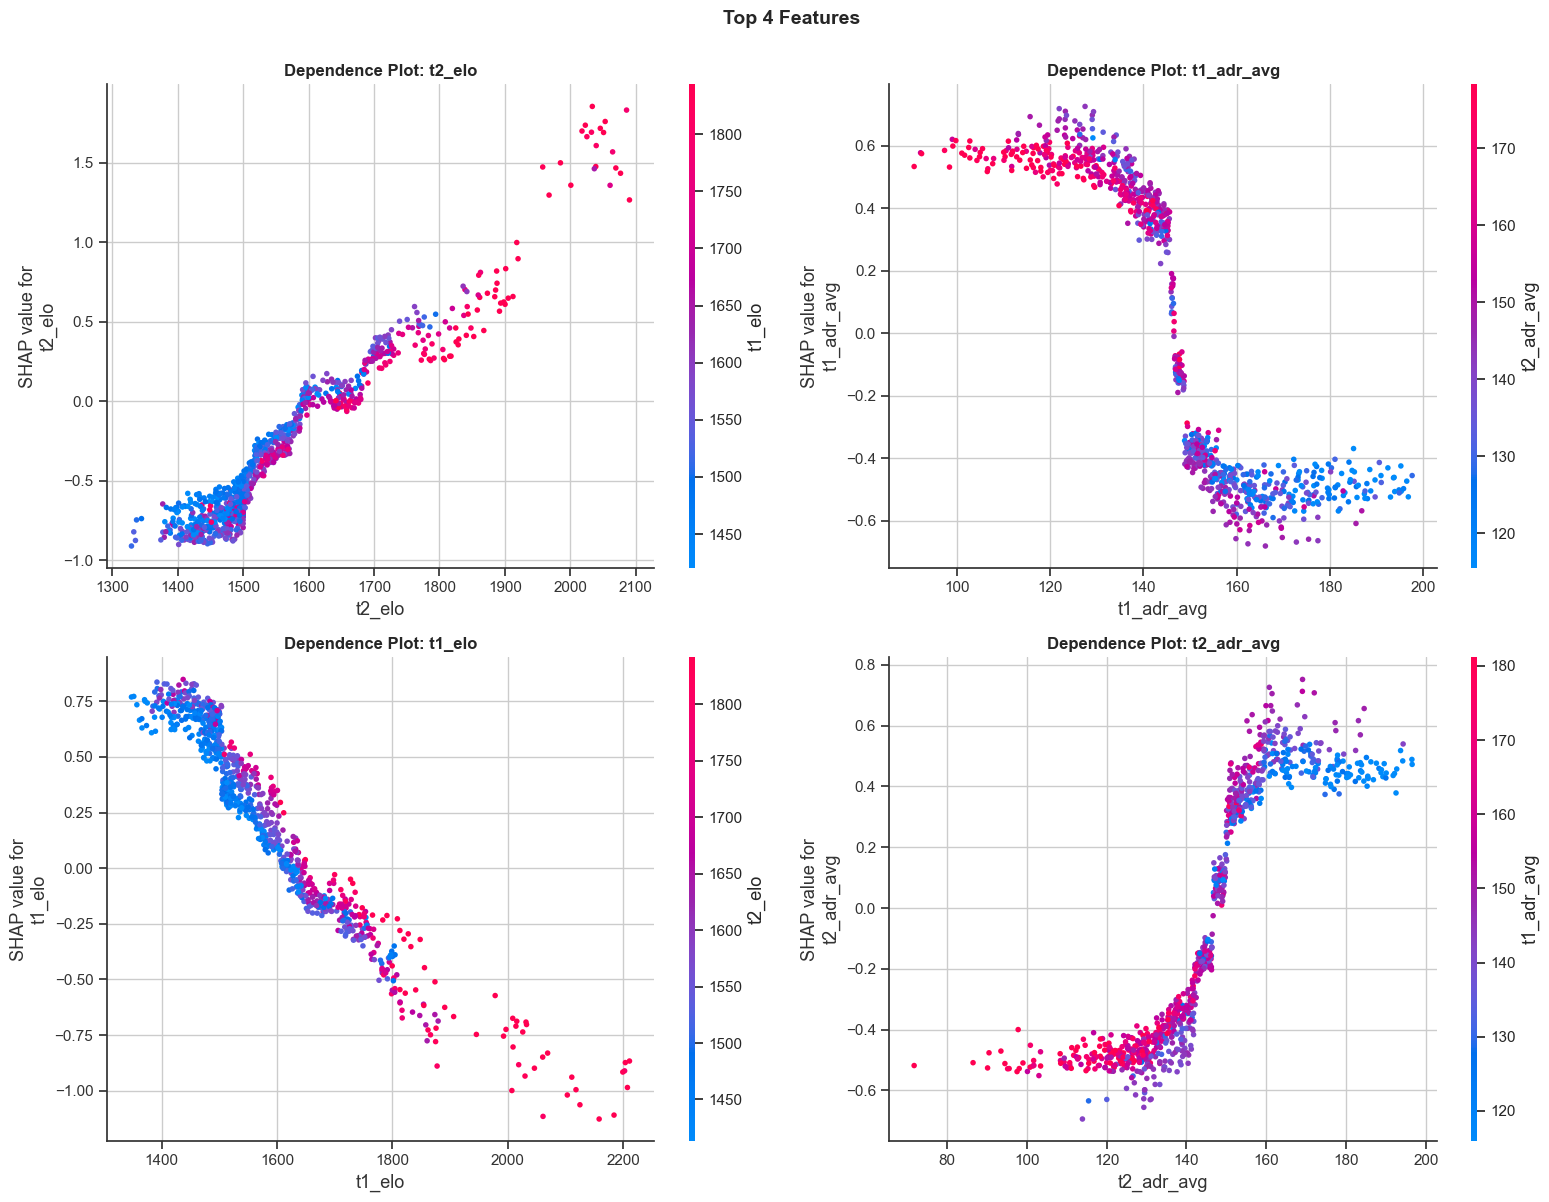

In [46]:
top_features = np.argsort(np.abs(shap_values).mean(0))[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature_idx in enumerate(top_features):
    feature_name = X_sample.columns[feature_idx]
    
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_sample,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Dependence Plot: {feature_name}', 
                        fontsize=12, fontweight='bold')

plt.suptitle('Top 4 Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

/Users/erikbayerlein/Documents/clutch-or-predict/.venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


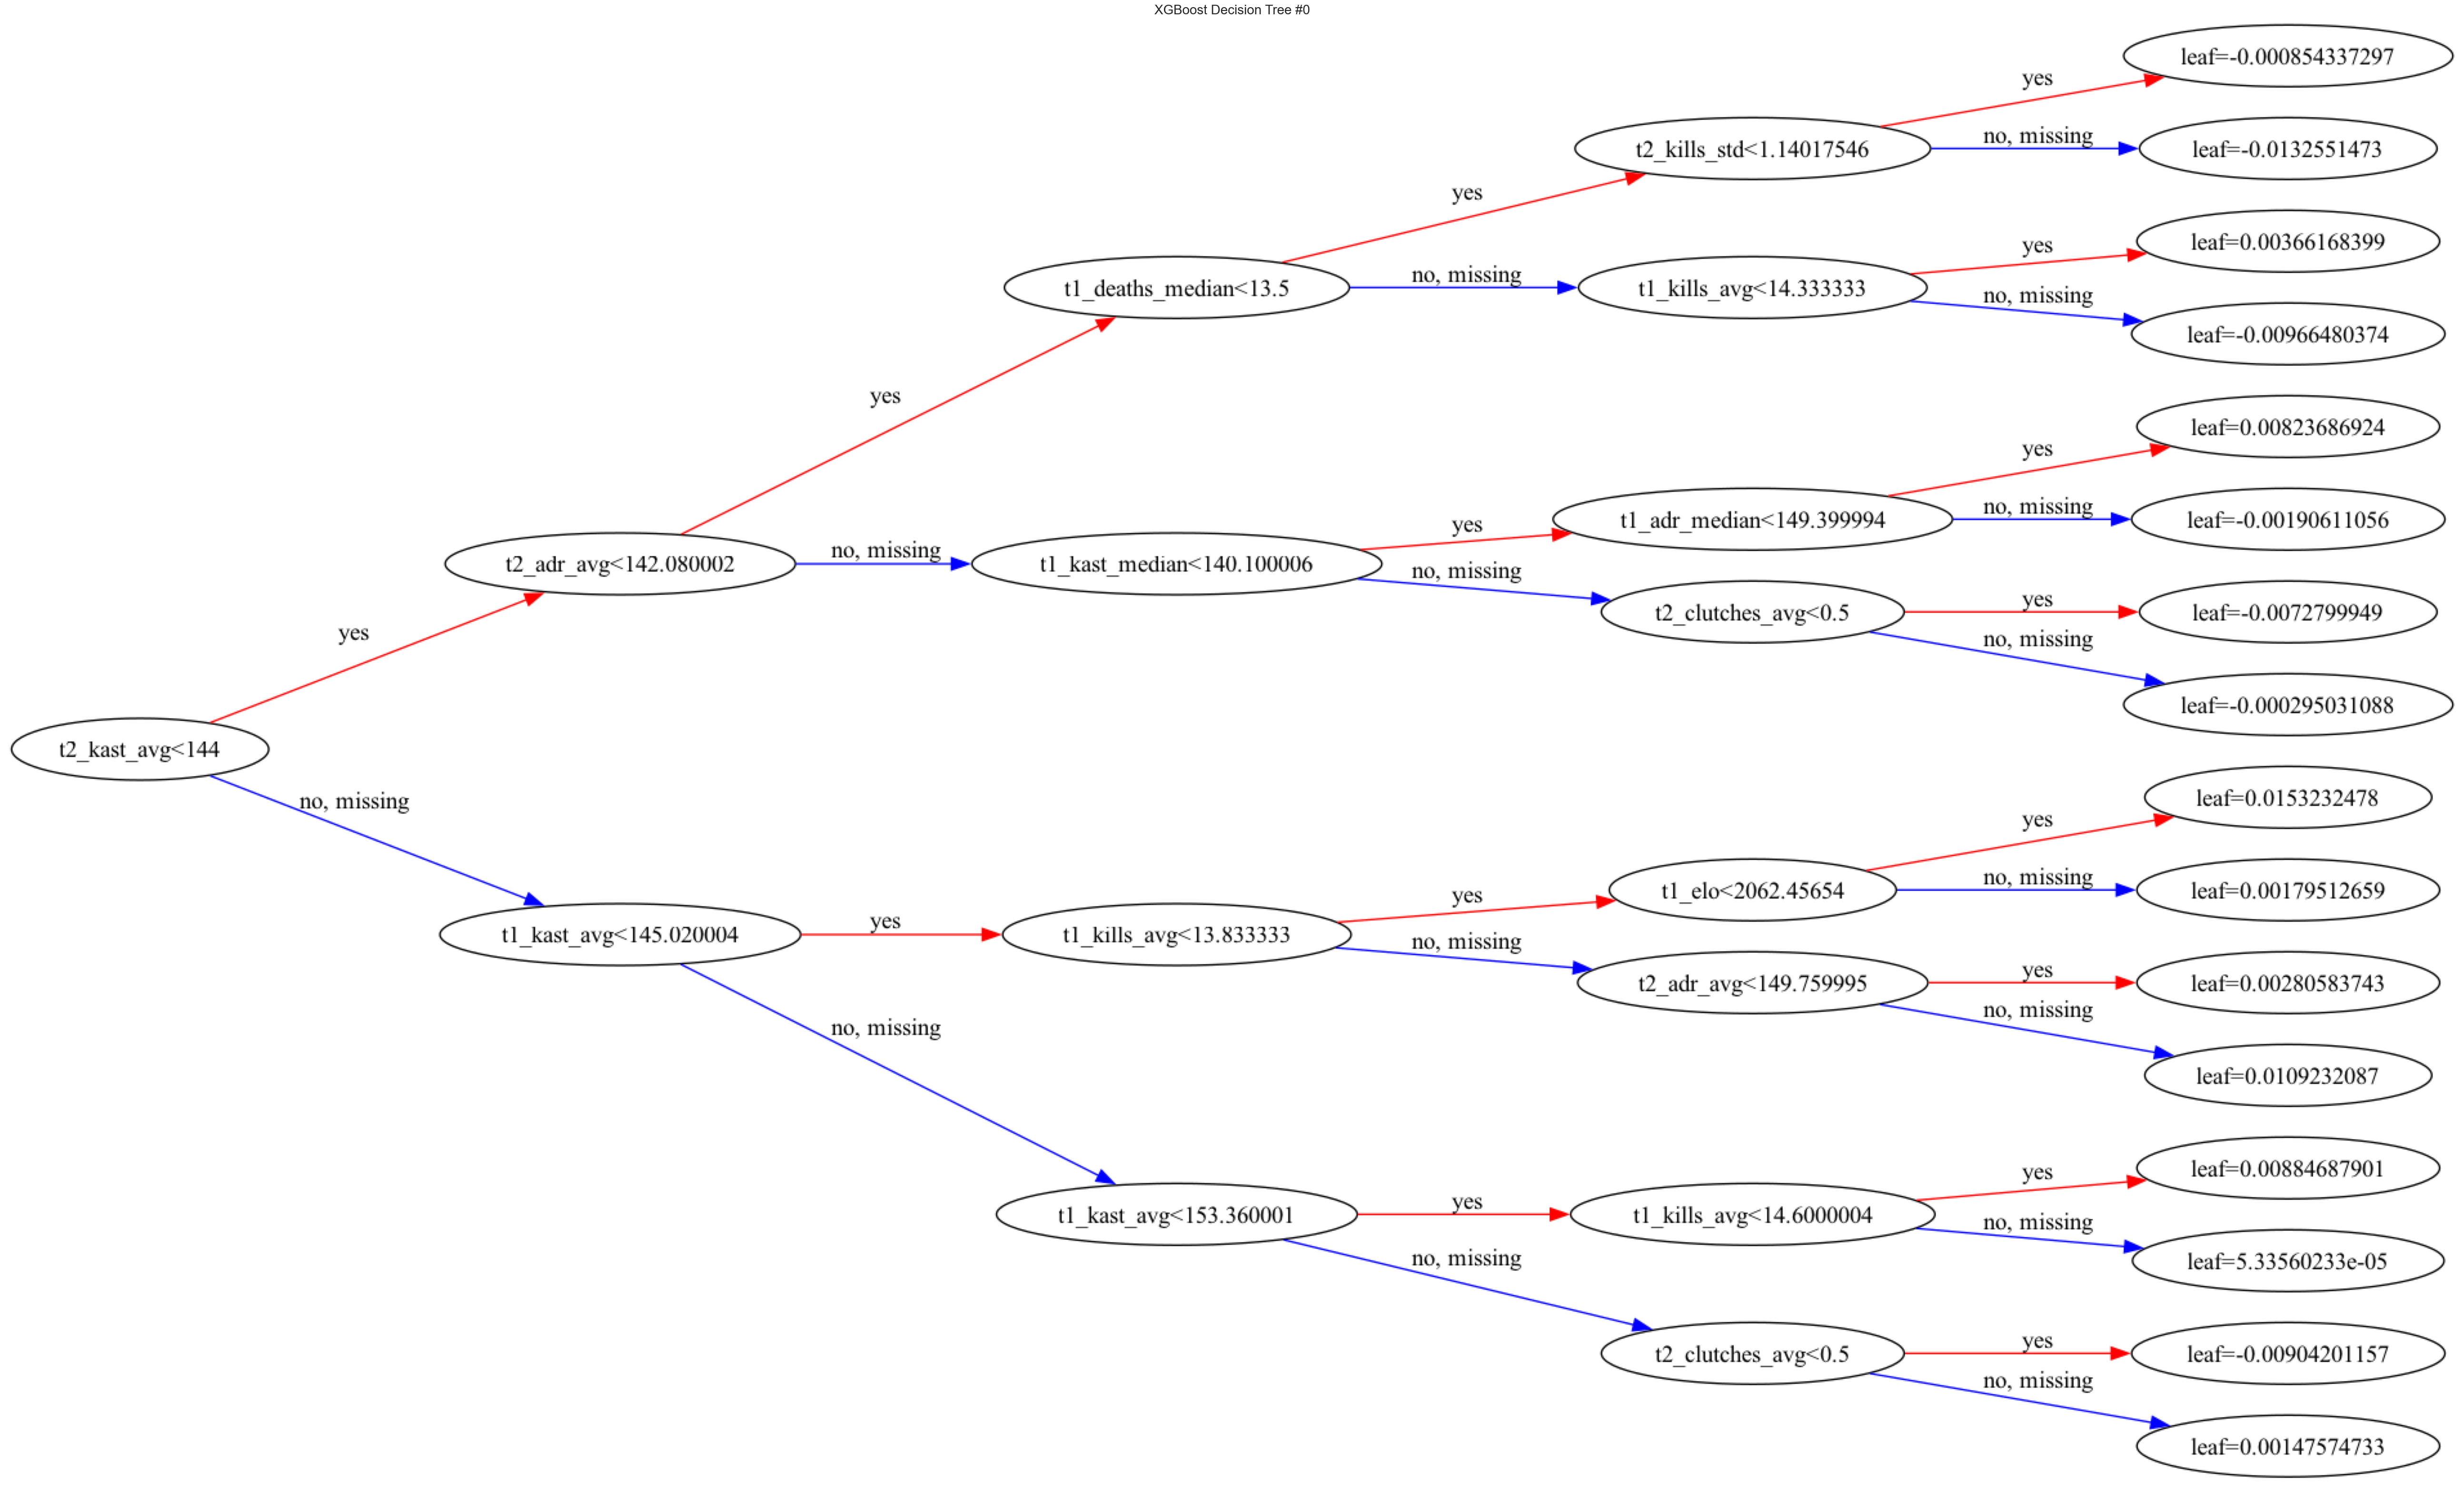

In [47]:
plt.rcParams['figure.figsize'] = [80, 40]

xgb.plot_tree(best_model, num_trees=0, rankdir='LR')

plt.title("XGBoost Decision Tree #0", fontsize=20)
plt.show()